In [1]:
!pip install pandas scikit-learn openpyxl matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import cdist

In [3]:
# Data penjualan Toko Asri Mart
data2022_2025 = pd.read_excel('Toko Asri Mart_2022-2025.xlsx')

# Menampilkan data
print("Data Penjualan Tahun 2022-2025:")
display(data2022_2025)

Data Penjualan Tahun 2022-2025:


,Item-no,Barcode,Nama Barang,Qty,Harga Jual,Unit,Total
0,140.0,000140,MIE 3 AYAM,900,4500,PCS,4050000
1,154.0,000154,MIE AA,700,5500,PCS,3850000
2,168.0,000168,INDOMIE KARI,2200,2900,PCS,6380000
3,504.0,000504,INDOMIE GOR RENDANG,1000,2900,PCS,2900000
4,490.0,000490,INDOMIE GORENG,2800,2950,PCS,8260000
...,...,...,...,...,...,...,...
4207,1386.0,001386,STELLA MATIC W FLOWER,150,28000,PCS,4200000
4208,1387.0,001387,HIT MAT C,150,6000,PCS,900000
4209,1388.0,001388,HIT ELECTRIK,150,9000,PCS,1350000
4210,1389.0,001389,LISTERIN SAKURA PEACH,200,19000,PCS,3800000


In [4]:
# Pilih hanya kolom 'Nama Barang' dan 'Qty'
data_selection = data2022_2025[['Nama Barang', 'Qty']].copy()

print("Data setelah pemilihan kolom 'Nama Barang' dan 'Qty':")
display(data_selection.head())

Data setelah pemilihan kolom 'Nama Barang' dan 'Qty':


,Nama Barang,Qty
0,MIE 3 AYAM,900
1,MIE AA,700
2,INDOMIE KARI,2200
3,INDOMIE GOR RENDANG,1000
4,INDOMIE GORENG,2800


In [5]:
# --- Preprocessing: Pemeriksaan dan Penanganan Nilai Null pada kolom 'Qty' ---

print("Memulai pemeriksaan dan penanganan nilai null di kolom 'Qty'...")

# 1. Tampilkan jumlah nilai null di kolom 'Qty' SEBELUM pembersihan
print("\nJumlah nilai null di kolom 'Qty' sebelum pembersihan:")
display(data_selection['Qty'].isnull().sum())

# 2. Membersihkan kolom 'Qty': mengganti string kosong/non-numerik menjadi NaN
#    dan mengkonversinya ke tipe data numerik.
print("Membersihkan dan mengkonversi kolom 'Qty' ke numerik...")
data_selection['Qty'] = (
    data_selection['Qty']
    .astype(str)
    .str.strip()
    .replace(['', ' ', 'NULL', 'NaN', 'nan', '-', '0'], np.nan) # Mengganti representasi null/kosong/nol dengan NaN
)
data_selection['Qty'] = pd.to_numeric(data_selection['Qty'], errors='coerce') # Konversi ke numerik, 'coerce' akan membuat nilai tidak valid menjadi NaN

# 3. Tampilkan jumlah nilai null di kolom 'Qty' SETELAH pembersihan (sebelum dihapus)
print("\nJumlah nilai null di kolom 'Qty' setelah pembersihan (sebelum dihapus):")
display(data_selection['Qty'].isnull().sum())

# 4. Menghapus baris dengan nilai NaN di kolom 'Qty'
print("Menghapus baris dengan nilai Qty yang hilang...")
data_selection.dropna(subset=['Qty'], inplace=True)

# 5. Tampilkan jumlah nilai null di kolom 'Qty' SETELAH dihapus
print("\nJumlah nilai null di kolom 'Qty' setelah dihapus:")
display(data_selection['Qty'].isnull().sum())

print(f"\nJumlah data setelah pembersihan dan penghapusan null: {len(data_selection)} baris.")
print("Preprocessing nilai null selesai.")

Memulai pemeriksaan dan penanganan nilai null di kolom 'Qty'...

Jumlah nilai null di kolom 'Qty' sebelum pembersihan:


np.int64(0)

Membersihkan dan mengkonversi kolom 'Qty' ke numerik...

Jumlah nilai null di kolom 'Qty' setelah pembersihan (sebelum dihapus):


np.int64(168)

Menghapus baris dengan nilai Qty yang hilang...

Jumlah nilai null di kolom 'Qty' setelah dihapus:


np.int64(0)


Jumlah data setelah pembersihan dan penghapusan null: 4044 baris.
Preprocessing nilai null selesai.


In [6]:
# --- Agregasi Data: Menjumlahkan 'Qty' berdasarkan 'Nama Barang' ---

print("Memulai agregasi data berdasarkan 'Nama Barang'...")

# Agregasi data_selection: kelompokkan berdasarkan 'Nama Barang' dan jumlahkan 'Qty'
df_aggregated_selection = data_selection.groupby('Nama Barang')['Qty'].sum().reset_index()

# Ganti nama kolom 'Qty' menjadi 'Total_Qty' atau 'Qty_Aggregated' untuk kejelasan
df_aggregated_selection.rename(columns={'Qty': 'Total_Qty'}, inplace=True)

print("Agregasi selesai. Berikut adalah 5 baris pertama dari data yang diagregasi:")
display(df_aggregated_selection.head())

print(f"\nJumlah unik barang setelah agregasi: {len(df_aggregated_selection)}.")

Memulai agregasi data berdasarkan 'Nama Barang'...
Agregasi selesai. Berikut adalah 5 baris pertama dari data yang diagregasi:


,Nama Barang,Total_Qty
0,ABC CHO KOPI,12800.0
1,ABC KECAP ASIN,2680.0
2,ABC MILK KOPI,13400.0
3,ABC SAMBAL 175ML,3200.0
4,ABC SAMBAL 8 GR,2750.0



Jumlah unik barang setelah agregasi: 561.


In [7]:
# --- Pemilihan Atribut Numerik untuk Clustering ---

print("Memilih atribut numerik untuk proses clustering...")

# Pilih kolom 'Total_Qty' sebagai atribut numerik
# .values.reshape(-1, 1) digunakan untuk mengubah Series menjadi array 2D,
# yang diperlukan oleh scaler dan model clustering sklearn.
qty_data = df_aggregated_selection[['Total_Qty']].values

print("Atribut numerik 'Total_Qty' telah dipilih dan siap untuk scaling. Berikut adalah 5 nilai pertama:")
display(qty_data[:5])

print(f"Bentuk data numerik: {qty_data.shape}")

Memilih atribut numerik untuk proses clustering...
Atribut numerik 'Total_Qty' telah dipilih dan siap untuk scaling. Berikut adalah 5 nilai pertama:


array([[12800.],
       [ 2680.],
       [13400.],
       [ 3200.],
       [ 2750.]])

Bentuk data numerik: (561, 1)


In [8]:
# --- Normalisasi Data dengan MinMaxScaler ---

print("Memulai normalisasi data 'Total_Qty' menggunakan MinMaxScaler...")

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Lakukan fitting dan transformasi data
scaled_data = scaler.fit_transform(qty_data)

print("Normalisasi selesai. Berikut adalah 5 nilai pertama dari data yang diskalakan:")
display(scaled_data[:5])

print(f"Bentuk data yang diskalakan: {scaled_data.shape}")

Memulai normalisasi data 'Total_Qty' menggunakan MinMaxScaler...
Normalisasi selesai. Berikut adalah 5 nilai pertama dari data yang diskalakan:


array([[0.38542047],
       [0.07752221],
       [0.40367531],
       [0.09334307],
       [0.07965194]])

Bentuk data yang diskalakan: (561, 1)


Memulai perhitungan WCSS untuk metode Elbow...


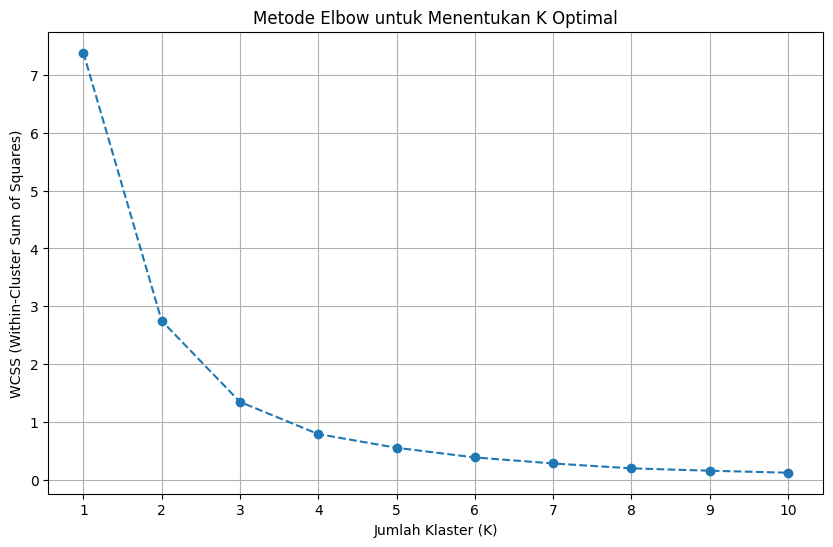

Silakan periksa plot di atas untuk menemukan 'titik siku' yang menunjukkan jumlah klaster optimal.


In [9]:
# --- Menentukan Jumlah Klaster Optimal dengan Metode Elbow ---

print("Memulai perhitungan WCSS untuk metode Elbow...")

wcss = []
# Mencoba jumlah klaster dari 1 hingga 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Memvisualisasikan hasil Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Silakan periksa plot di atas untuk menemukan 'titik siku' yang menunjukkan jumlah klaster optimal.")

In [10]:
# --- Inisialisasi Centroid Awal secara Acak ---

print("Menginisialisasi centroid awal secara acak...")

# Tentukan jumlah klaster (misalnya, k=3 dari hasil Elbow Method)
k_value = 3

# Pilih k_value data point secara acak dari scaled_data sebagai centroid awal
np.random.seed(42) # Untuk reproduksibilitas
random_indices = np.random.choice(scaled_data.shape[0], k_value, replace=False)
initial_centroids = scaled_data[random_indices]

print(f"Centroid awal yang diinisialisasi secara acak untuk {k_value} klaster:")
display(initial_centroids)

print("Inisialisasi centroid awal selesai.")

Menginisialisasi centroid awal secara acak...
Centroid awal yang diinisialisasi secara acak untuk 3 klaster:


array([[0.11616162],
       [0.00267738],
       [0.4158452 ]])

Inisialisasi centroid awal selesai.


In [28]:
# --- Menghitung Jarak Euclidean dari Setiap Data Point ke Centroid Awal ---

print("Menghitung jarak Euclidean dari setiap data point ke centroid awal...")

# Menghitung jarak Euclidean dari setiap data point (scaled_data) ke setiap centroid awal
# cdist(XA, XB) menghitung jarak antara setiap baris di XA dan setiap baris di XB.
# Di sini, XA adalah scaled_data dan XB adalah initial_centroids.
distances = cdist(scaled_data, initial_centroids, 'euclidean')

print("Matriks jarak berhasil dihitung. Berikut adalah 5 baris pertama dari matriks jarak:")

# Buat DataFrame untuk menampilkan Nama Barang bersama dengan jarak ke setiap centroid
columns_distances = [f'Jarak ke Centroid {i+1}' for i in range(initial_centroids.shape[0])]
distances_df = pd.DataFrame(distances, columns=columns_distances)
distances_df.insert(0, 'Nama Barang', df_aggregated_selection['Nama Barang'].reset_index(drop=True))

display(distances_df.head())

print(f"Bentuk matriks jarak: {distances.shape}")

Menghitung jarak Euclidean dari setiap data point ke centroid awal...
Matriks jarak berhasil dihitung. Berikut adalah 5 baris pertama dari matriks jarak:


,Nama Barang,Jarak ke Centroid 1,Jarak ke Centroid 2,Jarak ke Centroid 3
0,ABC CHO KOPI,0.269259,0.382743,0.030425
1,ABC KECAP ASIN,0.038639,0.074845,0.338323
2,ABC MILK KOPI,0.287514,0.400998,0.012170
3,ABC SAMBAL 175ML,0.022819,0.090666,0.322502
4,ABC SAMBAL 8 GR,0.036510,0.076975,0.336193


Bentuk matriks jarak: (561, 3)


In [19]:
# --- Mengelompokkan Data ke Centroid Terdekat ---

print("Mengelompokkan setiap titik data ke centroid terdekat...")

# Menentukan indeks centroid terdekat untuk setiap data point
# np.argmin akan mengembalikan indeks dari nilai minimum di sepanjang sumbu tertentu.
# axis=1 berarti mencari minimum di setiap baris (yaitu, untuk setiap data point).
cluster_labels = np.argmin(distances, axis=1);

# Mendapatkan jarak terdekat untuk setiap data point
nearest_distances = np.min(distances, axis=1);

print("Penetapan klaster selesai. Berikut adalah 10 baris pertama dengan Nama Barang, jarak terdekat, dan label klaster:")

# Buat DataFrame untuk menampilkan Nama Barang, Jarak Terdekat, dan Cluster Label
cluster_df = pd.DataFrame({
    'Nama Barang': df_aggregated_selection['Nama Barang'],
    'Jarak Terdekat': nearest_distances,
    'Cluster_Label': cluster_labels
});
display(cluster_df.head(10))

print(f"Jumlah data point yang diberi label: {len(cluster_labels)}")

Mengelompokkan setiap titik data ke centroid terdekat...
Penetapan klaster selesai. Berikut adalah 10 baris pertama dengan Nama Barang, jarak terdekat, dan label klaster:


,Nama Barang,Jarak Terdekat,Cluster_Label
0,ABC CHO KOPI,0.167838,2
1,ABC KECAP ASIN,0.013595,1
2,ABC MILK KOPI,0.149583,2
3,ABC SAMBAL 175ML,0.029416,1
4,ABC SAMBAL 8 GR,0.015724,1
5,ABC SARDINE SAMBAL TOMAT,0.058319,1
6,ABC SUSU,0.042954,0
7,ABC TERASI,0.058319,1
8,ABON AYAM PA' HARRIS,0.020481,1
9,ADEM SARI HGR,0.037022,1


Jumlah data point yang diberi label: 561


In [20]:
# --- Memperbarui Nilai Centroid ---

print("Memperbarui nilai centroid berdasarkan pengelompokan data...")

# Buat DataFrame sementara untuk menggabungkan scaled_data dan cluster_labels
temp_df = pd.DataFrame(scaled_data, columns=['Total_Qty_Scaled'])
temp_df['Cluster_Label'] = cluster_labels

# Hitung centroid baru sebagai mean dari setiap klaster
# np.array() digunakan untuk mengonversi hasil groupby.mean() menjadi array NumPy
new_centroids = np.array(temp_df.groupby('Cluster_Label')['Total_Qty_Scaled'].mean()).reshape(-1, 1)

print("Centroid yang diperbarui:")
# Tampilkan centroid dalam bentuk tabel (DataFrame)
display(pd.DataFrame(new_centroids, columns=['Centroid Value'], index=[f'Cluster {i}' for i in range(len(new_centroids))]))

print("Pembaharuan centroid selesai.")

Memperbarui nilai centroid berdasarkan pengelompokan data...
Centroid yang diperbarui:


,Centroid Value
Cluster 0,0.216923
Cluster 1,0.063928
Cluster 2,0.553258


Pembaharuan centroid selesai.


In [21]:
# --- Mengulang Proses K-Means hingga Konvergensi ---

print("Memulai iterasi K-Means hingga konvergensi...")

current_centroids = initial_centroids # Centroid awal
prev_centroids = None
iterations = 0
max_iterations = 100 # Batas iterasi untuk menghindari loop tak terbatas

while not np.array_equal(current_centroids, prev_centroids) and iterations < max_iterations:
    prev_centroids = current_centroids.copy()
    iterations += 1
    print(f"\n--- Iterasi {iterations} ---")

    # 1. Menghitung Jarak Euclidean dari Setiap Data Point ke Centroid Saat Ini
    distances = cdist(scaled_data, current_centroids, 'euclidean')

    # 2. Mengelompokkan Data ke Centroid Terdekat
    cluster_labels = np.argmin(distances, axis=1)

    # 3. Memperbarui Nilai Centroid
    # Buat DataFrame sementara untuk menggabungkan scaled_data dan cluster_labels
    temp_df = pd.DataFrame(scaled_data, columns=['Total_Qty_Scaled'])
    temp_df['Cluster_Label'] = cluster_labels

    # Hitung centroid baru sebagai mean dari setiap klaster
    # Handle kasus klaster kosong (meskipun jarang dengan k-means++)
    new_centroids = np.zeros_like(current_centroids)
    for i in range(k_value):
        if i in temp_df['Cluster_Label'].unique():
            new_centroids[i] = temp_df[temp_df['Cluster_Label'] == i]['Total_Qty_Scaled'].mean()
        else:
            # Jika klaster kosong, biarkan centroid tetap atau inisialisasi ulang
            # Untuk kesederhanaan, kita bisa membiarkannya sama untuk iterasi ini
            new_centroids[i] = current_centroids[i]

    current_centroids = new_centroids

    print("Centroid yang diperbarui:")
    display(current_centroids)

print(f"\nProses K-Means konvergen setelah {iterations} iterasi.")
print("Centroid akhir:")
display(current_centroids)

# Simpan cluster_labels terakhir untuk penggunaan selanjutnya
final_cluster_labels = cluster_labels

Memulai iterasi K-Means hingga konvergensi...

--- Iterasi 1 ---
Centroid yang diperbarui:


array([[0.11663844],
       [0.03422108],
       [0.41877012]])


--- Iterasi 2 ---
Centroid yang diperbarui:


array([[0.13304   ],
       [0.04324038],
       [0.41877012]])


--- Iterasi 3 ---
Centroid yang diperbarui:


...

array([[0.21692265],
       [0.06392755],
       [0.55325849]])


--- Iterasi 14 ---
Centroid yang diperbarui:


array([[0.21692265],
       [0.06392755],
       [0.55325849]])


Proses K-Means konvergen setelah 14 iterasi.
Centroid akhir:


array([[0.21692265],
       [0.06392755],
       [0.55325849]])

In [22]:
# --- Menggabungkan Label Klaster ke Data Agregasi dan Memberi Nama Kategori ---

print("Menggabungkan label klaster ke data agregasi...")

# Tambahkan cluster_labels ke DataFrame yang diagregasi
df_agg_clustered = df_aggregated_selection.copy()
df_agg_clustered['Cluster_Label_Numeric'] = final_cluster_labels

# Urutkan centroid akhir untuk menentukan urutan kategori
# current_centroids adalah array 2D, kita perlu meratakannya untuk sorting
centroid_values_sorted = np.sort(current_centroids.flatten())

# Buat mapping dari nilai centroid ke label kategori
# Asumsi: klaster dengan nilai centroid terkecil adalah 'Kurang Laris', dst.
centroid_to_category = {}

# Temukan indeks klaster asli dari centroid yang sudah diurutkan
for i, sorted_val in enumerate(centroid_values_sorted):
    # Cari indeks asli dari nilai centroid ini di current_centroids
    original_idx = np.where(current_centroids.flatten() == sorted_val)[0][0]
    if i == 0:
        centroid_to_category[original_idx] = 'Kurang Laris'
    elif i == 1:
        centroid_to_category[original_idx] = 'Sedang'
    else:
        centroid_to_category[original_idx] = 'Laris'

# Map label numerik ke label kategori
df_agg_clustered['Kategori_Penjualan'] = df_agg_clustered['Cluster_Label_Numeric'].map(centroid_to_category)

print("Pengelompokan data selesai. Berikut adalah 10 baris pertama dengan kategori penjualan:")
display(df_agg_clustered.head(10))

print("\nRingkasan jumlah produk per kategori:")
display(df_agg_clustered['Kategori_Penjualan'].value_counts())

Menggabungkan label klaster ke data agregasi...
Pengelompokan data selesai. Berikut adalah 10 baris pertama dengan kategori penjualan:


,Nama Barang,Total_Qty,Cluster_Label_Numeric,Kategori_Penjualan
0,ABC CHO KOPI,12800.0,2,Laris
1,ABC KECAP ASIN,2680.0,1,Kurang Laris
2,ABC MILK KOPI,13400.0,2,Laris
3,ABC SAMBAL 175ML,3200.0,1,Kurang Laris
4,ABC SAMBAL 8 GR,2750.0,1,Kurang Laris
5,ABC SARDINE SAMBAL TOMAT,4150.0,1,Kurang Laris
6,ABC SUSU,5850.0,0,Sedang
7,ABC TERASI,4150.0,1,Kurang Laris
8,ABON AYAM PA' HARRIS,1560.0,1,Kurang Laris
9,ADEM SARI HGR,3450.0,1,Kurang Laris



Ringkasan jumlah produk per kategori:


,count
Kategori_Penjualan,
Kurang Laris,439
Sedang,102
Laris,20


In [23]:
# --- Menghitung Silhouette Score ---

print("Menghitung Silhouette Score untuk evaluasi klastering...")

# Pastikan k_value > 1 untuk menghitung Silhouette Score
if k_value > 1:
    # Hitung Silhouette Score
    # scaled_data: data input yang telah diskalakan
    # final_cluster_labels: label klaster yang dihasilkan dari K-Means terakhir
    silhouette_avg = silhouette_score(scaled_data, final_cluster_labels)
    print(f"Silhouette Score: {silhouette_avg:.4f}")
    print("\nInterpretasi Silhouette Score:")
    print("- Nilai mendekati +1 menunjukkan bahwa objek berada jauh dari klaster tetangga (klaster yang jelas).")
    print("- Nilai mendekati 0 menunjukkan bahwa objek berada di antara dua klaster atau di perbatasan klaster.")
    print("- Nilai mendekati -1 menunjukkan bahwa objek mungkin telah salah dikelompokkan.")
else:
    print("Silhouette Score tidak dapat dihitung untuk k=1.")


Menghitung Silhouette Score untuk evaluasi klastering...
Silhouette Score: 0.6655

Interpretasi Silhouette Score:
- Nilai mendekati +1 menunjukkan bahwa objek berada jauh dari klaster tetangga (klaster yang jelas).
- Nilai mendekati 0 menunjukkan bahwa objek berada di antara dua klaster atau di perbatasan klaster.
- Nilai mendekati -1 menunjukkan bahwa objek mungkin telah salah dikelompokkan.


Membuat scatter plot hasil klastering dengan visualisasi PCA...


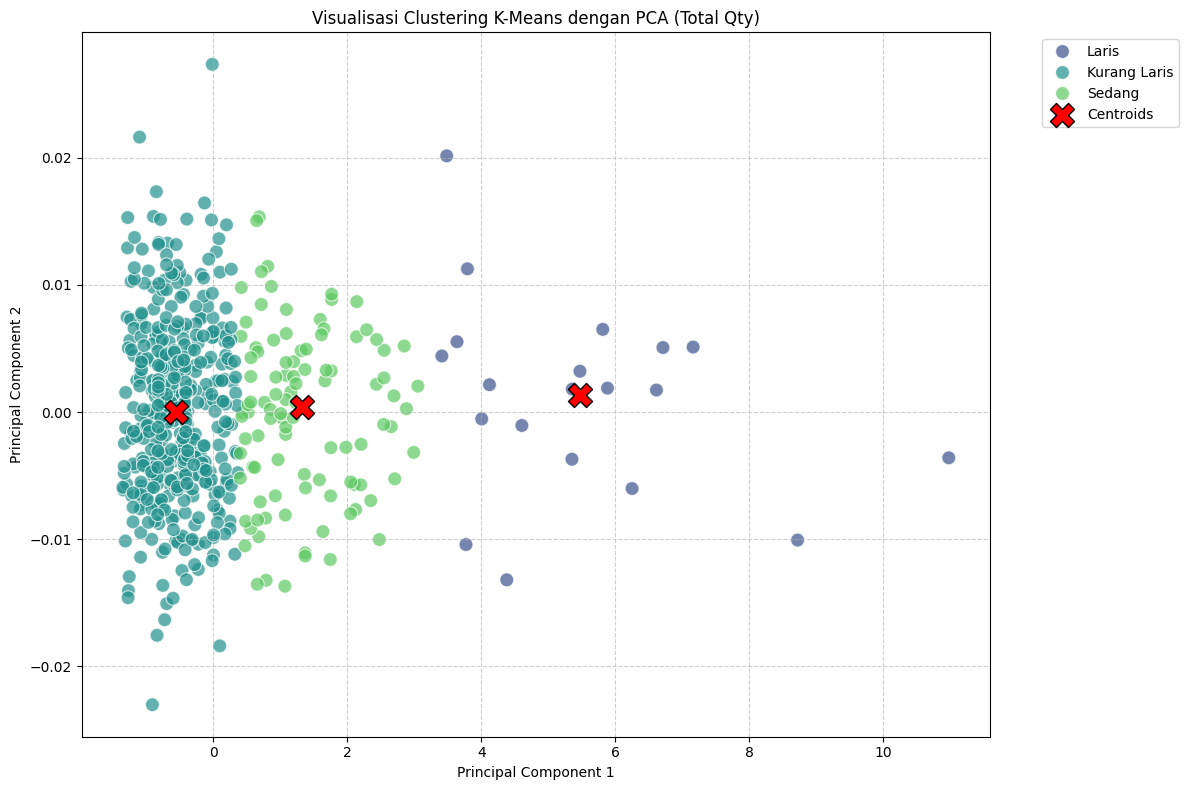

Visualisasi clustering K-Means dengan PCA telah ditampilkan.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Membuat scatter plot hasil klastering dengan visualisasi PCA...")

# 1. Ambil data Qty asli untuk scaling PCA (qty_data adalah data Total_Qty sebelum MinMax scaling)
X_for_pca_original_qty = qty_data

# 2. Standardisasi data untuk PCA
scaler_pca = StandardScaler()
X_standard_scaled_for_pca = scaler_pca.fit_transform(X_for_pca_original_qty)

# 3. Duplikasi fitur + sedikit noise (untuk membuat 2 dimensi agar PCA bisa diplot)
#    Ini adalah workaround visualisasi untuk data 1-dimensi.
np.random.seed(42) # Untuk reproduksibilitas noise
X_fake_pca_input = np.hstack([
    X_standard_scaled_for_pca,
    X_standard_scaled_for_pca + np.random.normal(0, 0.01, X_standard_scaled_for_pca.shape) # Tambahkan noise kecil
])

# 4. PCA ke 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_fake_pca_input)

# 5. DataFrame hasil PCA
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# Tambahkan label kategori dari df_agg_clustered (pastikan indeks sejajar)
df_pca['Kategori_Penjualan'] = df_agg_clustered['Kategori_Penjualan'].reset_index(drop=True)

# 6. Transform centroid ke ruang PCA
# Centroid (current_centroids) saat ini adalah MinMaxScaled. Kita perlu mengembalikannya ke skala asli
# lalu StandardScale, dan membuat input 2D 'fake' untuk PCA.
centroids_original_qty_scale = scaler.inverse_transform(current_centroids) # Inverse transform dari MinMaxScaler
centroids_standard_scaled_for_pca = scaler_pca.transform(centroids_original_qty_scale) # Standard scale

# Buat input 2D 'fake' untuk centroid, tanpa menambahkan noise pada centroid itu sendiri
centroids_fake_pca_input = np.hstack([
    centroids_standard_scaled_for_pca,
    centroids_standard_scaled_for_pca
])
centroids_pca = pca.transform(centroids_fake_pca_input)

# 7. Plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Kategori_Penjualan', # Menggunakan kategori penjualan untuk warna
    palette='viridis',
    data=df_pca,
    s=100,
    alpha=0.7
)

# Plot centroid
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    s=300,
    marker='X',
    edgecolors='black',
    label='Centroids',
    zorder=5
)

plt.title('Visualisasi Clustering K-Means dengan PCA (Total Qty)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Visualisasi clustering K-Means dengan PCA telah ditampilkan.")

10 Barang Terlaris (2022-2025):


,Nama Barang,Total_Qty,Cluster_Label_Numeric,Kategori_Penjualan
196,GERY SALUUT COCO RLL 7GR,33000.0,2,Laris
14,AQUA CUBE,27000.0,2,Laris
186,GERY COKLUT EGGROLL KRIM KELAPA,22800.0,2,Laris
183,GERRY WAFER CREAM KELAPA TABUR,21600.0,2,Laris
176,GARUDA KCG KULIT 27G,21350.0,2,Laris
182,GERRY CHOCOLATOS ROLL,20400.0,2,Laris
198,GERY SN SER BANTAL,19400.0,2,Laris
185,GERY COKLAT TABUR PANJANG,19200.0,2,Laris
144,DOWNY PARFUM 20ML,18300.0,2,Laris
228,INDOMIE SOTO,18000.0,2,Laris


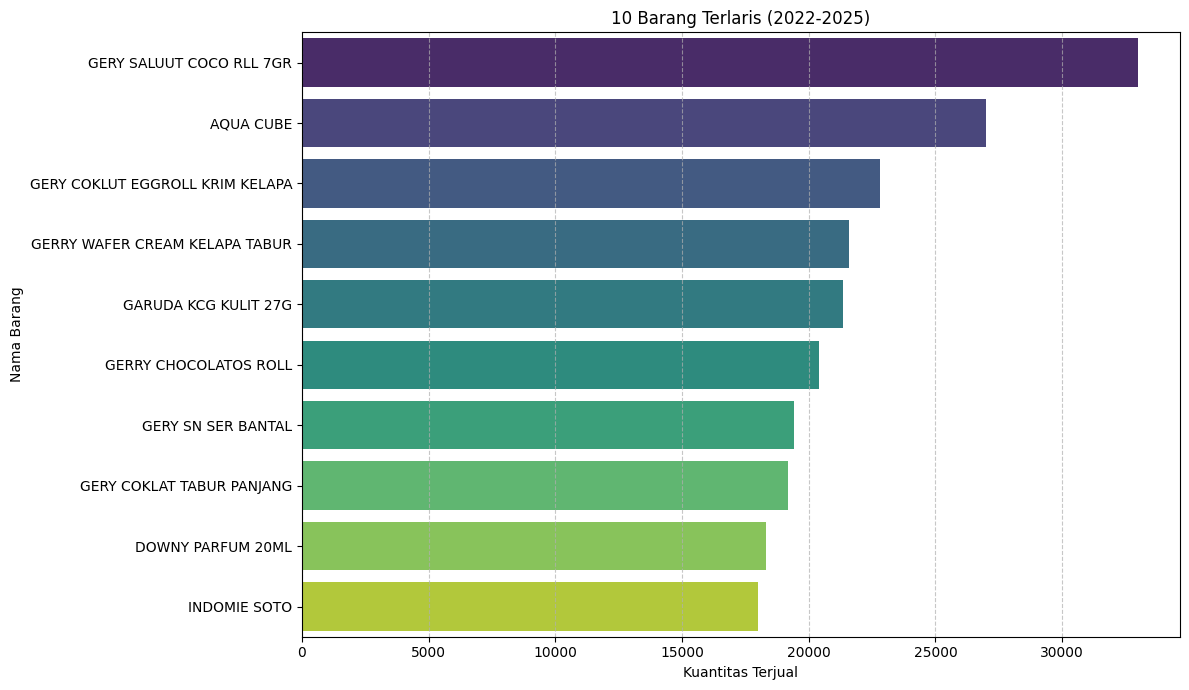

In [26]:
# Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

print("10 Barang Terlaris (2022-2025):")
# Urutkan DataFrame berdasarkan Qty_2022_2025 secara menurun dan ambil 10 teratas
barang_terlaris = df_agg_clustered.sort_values(by='Total_Qty', ascending=False).head(10)
display(barang_terlaris)

# Membuat diagram batang untuk 10 barang terlaris
plt.figure(figsize=(12, 7))
sns.barplot(x='Total_Qty', y='Nama Barang', data=barang_terlaris, palette='viridis', hue='Nama Barang', legend=False)
plt.title('10 Barang Terlaris (2022-2025)')
plt.xlabel('Kuantitas Terjual')
plt.ylabel('Nama Barang')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
# =========================================================================
# AMBIL RANGE QTY OTOMATIS KHUSUS K = 3 UNTUK LAPORAN
# =========================================================================

# Menggunakan optimal_k dan df_agg_clustered yang sudah ada
# Pastikan df_agg_clustered memiliki kolom 'Total_Qty' dan 'Kategori_Penjualan'

if k_value == 3: # Menggunakan k_value karena optimal_k tidak didefinisikan secara global, k_value adalah jumlah klaster yang digunakan
    info_list = []
    # Urutan kategori sesuai dengan hasil pengurutan centroid: Kurang Laris, Sedang, Laris
    for kat in ["Kurang Laris", "Sedang", "Laris"]:
        # Filter subset berdasarkan 'Kategori_Penjualan'
        subset = df_agg_clustered[df_agg_clustered['Kategori_Penjualan'] == kat]
        if not subset.empty:
            min_val = subset['Total_Qty'].min()
            max_val = subset['Total_Qty'].max()
            # Format angka dengan pemisah ribuan
            info_list.append(f"{kat}: {min_val:,.0f} s.d. {max_val:,.0f}")

    # Ini akan memunculkan teks kecil di web kamu yang berisi angka range otomatis dari Python
    print(f"💡 **Range Qty Otomatis (K={k_value}) untuk Laporan:** " + " | ".join(info_list))
else:
    print(f"Range Qty Otomatis hanya tersedia untuk K=3. Saat ini K={k_value}.")

💡 **Range Qty Otomatis (K=3) untuk Laporan:** Kurang Laris: 132 s.d. 4,700 | Sedang: 4,800 s.d. 11,850 | Laris: 12,800 s.d. 33,000
